<a href="https://colab.research.google.com/github/molluIdontknow/ELE_Algorithm/blob/%EA%B9%80%EC%8B%9C%EC%9A%B0/Eliopolis(MLP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)

In [42]:
CSV_FILENAME = "merged_features.csv"
TARGET = "soh_label_pct"

# Cross Validation
N_SPLITS = 5

# Training
BATCH_SIZE = 5
MAX_EPOCHS = 2000
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4

# Learning Rate Scheduler
SCHEDULER_PATIENCE = 15
SCHEDULER_FACTOR = 0.5
MIN_LR = 1e-6

# Early Stopping
EARLY_STOPPING_PATIENCE = 60
MIN_EPOCHS = 100

# Permutation Importance
PERMUTATION_REPEATS = 30

# Seed
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [43]:
# ============================================================
# 3. DATA LOAD
# ============================================================

df = pd.read_csv(CSV_FILENAME)

# target만 제외하고 나머지 column을 모두 feature로 사용
X = df.drop(columns=[TARGET])
y = df[TARGET]

FEATURES = X.columns.tolist()
X_ALL = X.to_numpy(dtype=np.float32)
Y_ALL = y.to_numpy(dtype=np.float32)
N_FEATURES = X.shape[1]

In [44]:
# ============================================================
# 4. MLP MODEL
# ============================================================
class SOHMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.network(x)

In [45]:
# ============================================================
# 5. TRAIN ONE FOLD
# ============================================================
def train_one_fold(X_train_raw, y_train_raw, X_val_raw, y_val_raw, seed):
    set_seed(seed)

    # --------------------------------------------------------
    # X Scaling
    # --------------------------------------------------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_val = scaler.transform(X_val_raw)

    # --------------------------------------------------------
    # Tensor
    # --------------------------------------------------------
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_raw, dtype=torch.float32).unsqueeze(1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val_raw, dtype=torch.float32).unsqueeze(1).to(DEVICE)

    # --------------------------------------------------------
    # DataLoader
    # --------------------------------------------------------
    dataset = TensorDataset(X_train_t, y_train_t)
    generator = torch.Generator()
    generator.manual_seed(seed)
    train_loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------
    model = SOHMLP(input_dim=X_train.shape[1]).to(DEVICE)

    with torch.no_grad():
        model.network[-1].bias.fill_(float(np.mean(y_train_raw)))

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=SCHEDULER_FACTOR,
        patience=SCHEDULER_PATIENCE,
        min_lr=MIN_LR
    )

    # --------------------------------------------------------
    # Training Variables
    # --------------------------------------------------------
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    patience_counter = 0
    train_history = []
    val_history = []

    # ========================================================
    # TRAINING
    # ========================================================
    for epoch in range(1, MAX_EPOCHS + 1):
        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------
        model.train()
        total_train_loss = 0.0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad()

            prediction = model(batch_x)
            loss = criterion(prediction, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_train_loss += loss.item() * batch_x.size(0)

        train_loss = total_train_loss / len(dataset)

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------
        model.eval()

        with torch.no_grad():
            val_prediction = model(X_val_t)
            val_loss = criterion(val_prediction, y_val_t).item()

        train_history.append(train_loss)
        val_history.append(val_loss)

        # ----------------------------------------------------
        # Best Model
        # ----------------------------------------------------
        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        # ----------------------------------------------------
        # Learning Rate Scheduler
        # ----------------------------------------------------
        old_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]["lr"]

        # LR이 감소했으면
        # 새 learning rate가 학습할 시간을 다시 줌
        if new_lr < old_lr:
            patience_counter = 0

        # ----------------------------------------------------
        # Early Stopping
        # ----------------------------------------------------
        if epoch >= MIN_EPOCHS and patience_counter >= EARLY_STOPPING_PATIENCE:
            break

    # ========================================================
    # RESTORE BEST MODEL
    # ========================================================
    model.load_state_dict(best_state)
    model.eval()

    # --------------------------------------------------------
    # Final Validation Prediction
    # --------------------------------------------------------
    with torch.no_grad():
        prediction = model(X_val_t).cpu().numpy().flatten()

    return {
        "model": model,
        "scaler": scaler,
        "prediction": prediction,
        "train_history": train_history,
        "val_history": val_history
    }

In [46]:
# ============================================================
# 6. 5-FOLD CROSS VALIDATION
# ============================================================

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# 각 sample의 validation prediction 저장
oof_prediction = np.zeros(len(Y_ALL), dtype=np.float32)

fold_models = []
fold_indices = []
fold_histories = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_ALL)):
    # --------------------------------------------------------
    # Split
    # --------------------------------------------------------
    X_train = X_ALL[train_idx]
    X_val = X_ALL[val_idx]

    y_train = Y_ALL[train_idx]
    y_val = Y_ALL[val_idx]

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------
    result = train_one_fold(
        X_train,
        y_train,
        X_val,
        y_val,
        seed=SEED + fold
    )

    # --------------------------------------------------------
    # OOF Prediction
    # --------------------------------------------------------
    oof_prediction[val_idx] = result["prediction"]

    # --------------------------------------------------------
    # Store Model
    # --------------------------------------------------------
    fold_models.append({
        "model": result["model"],
        "scaler": result["scaler"]
    })

    # --------------------------------------------------------
    # Store Indices
    # --------------------------------------------------------
    fold_indices.append({
        "train": train_idx,
        "val": val_idx
    })

    # --------------------------------------------------------
    # Store Loss
    # --------------------------------------------------------
    fold_histories.append({
        "train": result["train_history"],
        "val": result["val_history"]
    })

In [47]:
# ============================================================
# 7. MODEL PERFORMANCE
# ============================================================

MSE = mean_squared_error(Y_ALL, oof_prediction)
MAE = mean_absolute_error(Y_ALL, oof_prediction)
R2 = r2_score(Y_ALL, oof_prediction)

# ------------------------------------------------------------
# Error Rate
# ------------------------------------------------------------
error_rate = (np.abs(Y_ALL - oof_prediction) / np.abs(Y_ALL)) * 100

print(f"MSE     : {MSE:.6f}")
print(f"MAE     : {MAE:.6f}")
print(f"R-score : {R2:.6f}")

print("\nError Rate Stats")
print(f"Mean    : {np.mean(error_rate):.4f}%")
print(f"Median  : {np.median(error_rate):.4f}%")
print(f"Std     : {np.std(error_rate):.4f}%")
print(f"Min     : {np.min(error_rate):.4f}%")
print(f"Max     : {np.max(error_rate):.4f}%")
print(f"95%     : {np.percentile(error_rate, 95):.4f}%")

MSE     : 0.288356
MAE     : 0.380418
R-score : 0.993738

Error Rate Stats
Mean    : 0.4294%
Median  : 0.2927%
Std     : 0.4364%
Min     : 0.0022%
Max     : 2.4126%
95%     : 1.2920%


In [48]:
# ============================================================
# 8. PERMUTATION FEATURE IMPORTANCE
# ============================================================

importance_results = {feature: [] for feature in FEATURES}

for fold in range(N_SPLITS):
    # --------------------------------------------------------
    # Fold data
    # --------------------------------------------------------
    val_idx = fold_indices[fold]["val"]
    X_val_raw = X_ALL[val_idx]
    y_val = Y_ALL[val_idx]

    # --------------------------------------------------------
    # Model / Scaler
    # --------------------------------------------------------
    model = fold_models[fold]["model"]
    scaler = fold_models[fold]["scaler"]
    model.eval()

    # --------------------------------------------------------
    # Baseline prediction
    # --------------------------------------------------------
    X_val_scaled = scaler.transform(X_val_raw)
    X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        baseline_prediction = model(X_val_t).cpu().numpy().flatten()

    baseline_mse = mean_squared_error(y_val, baseline_prediction)

    # Fold마다 동일하게 재현 가능한 random generator
    rng = np.random.default_rng(SEED + 1000 + fold)

    # ========================================================
    # Each Feature
    # ========================================================
    for feature_index, feature in enumerate(FEATURES):
        repeat_scores = []

        for _ in range(PERMUTATION_REPEATS):
            # 원본 validation 복사
            X_permuted = X_val_raw.copy()

            # 해당 feature만 shuffle
            shuffled_column = X_permuted[:, feature_index].copy()
            rng.shuffle(shuffled_column)
            X_permuted[:, feature_index] = shuffled_column

            # ------------------------------------------------
            # Scaling
            # ------------------------------------------------
            X_permuted_scaled = scaler.transform(X_permuted)
            X_permuted_t = torch.tensor(X_permuted_scaled, dtype=torch.float32).to(DEVICE)

            # ------------------------------------------------
            # Prediction
            # ------------------------------------------------
            with torch.no_grad():
                prediction = model(X_permuted_t).cpu().numpy().flatten()

            # ------------------------------------------------
            # Permuted MSE
            # ------------------------------------------------
            permuted_mse = mean_squared_error(y_val, prediction)

            # MSE가 얼마나 증가했는지
            importance = permuted_mse - baseline_mse
            repeat_scores.append(importance)

        # 30회 결과를 모두 저장
        importance_results[feature].extend(repeat_scores)

In [49]:
# ============================================================
# 9. FEATURE IMPORTANCE DATA
# ============================================================

feature_importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": [np.mean(importance_results[feature]) for feature in FEATURES],
    "Std": [np.std(importance_results[feature]) for feature in FEATURES]
})

# 중요도가 낮은 feature부터 정렬
feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=True
).reset_index(drop=True)

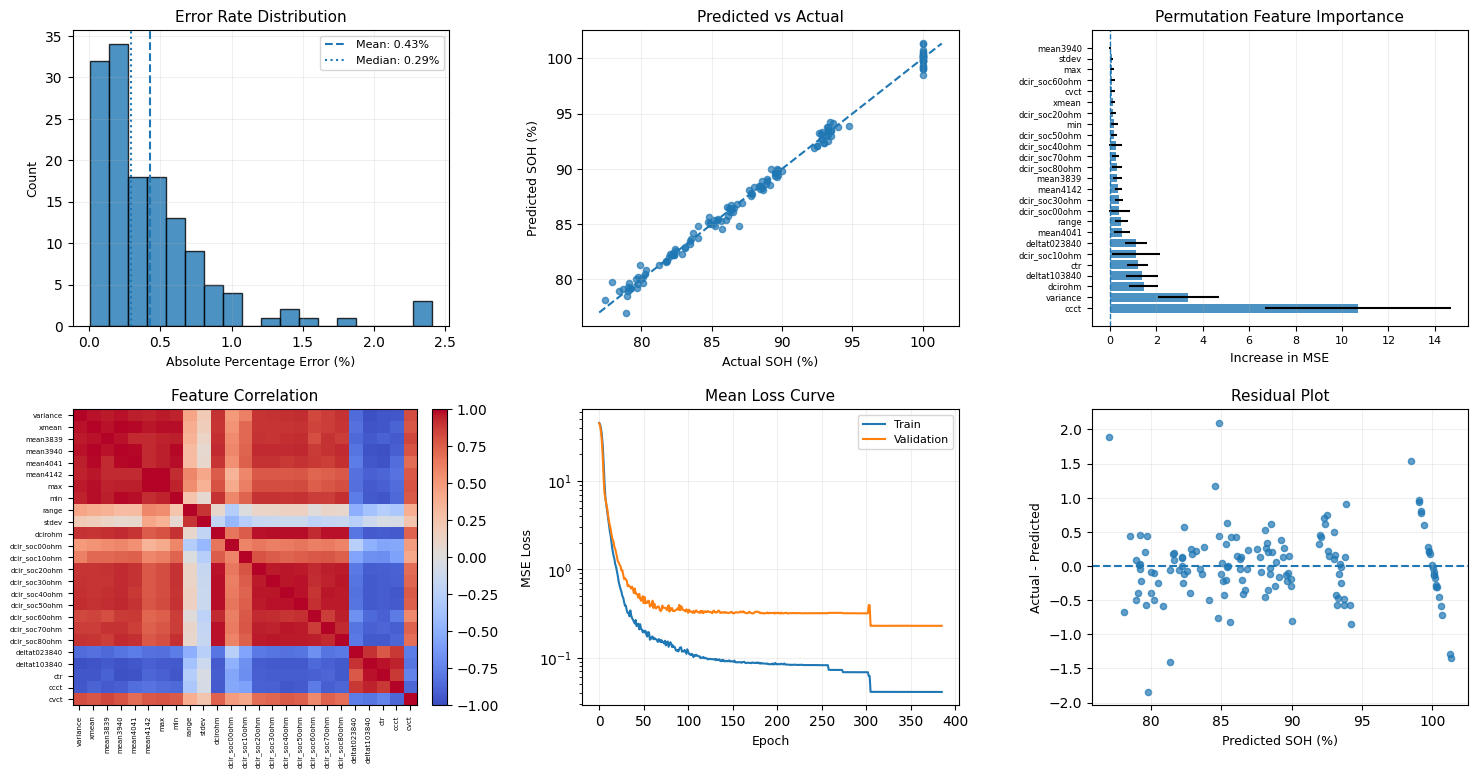

In [50]:
# ============================================================
# 10. VISUALIZATION
# ============================================================

# ------------------------------------------------------------
# Data for visualization
# ------------------------------------------------------------
residuals = Y_ALL - oof_prediction

# ------------------------------------------------------------
# Mean Loss Curve
# ------------------------------------------------------------
max_length = max(len(history["train"]) for history in fold_histories)

train_matrix = np.full((N_SPLITS, max_length), np.nan)
val_matrix = np.full((N_SPLITS, max_length), np.nan)

for fold, history in enumerate(fold_histories):
    train_len = len(history["train"])
    val_len = len(history["val"])

    train_matrix[fold, :train_len] = history["train"]
    val_matrix[fold, :val_len] = history["val"]

mean_train_loss = np.nanmean(train_matrix, axis=0)
mean_val_loss = np.nanmean(val_matrix, axis=0)

# ------------------------------------------------------------
# Feature Importance
# ------------------------------------------------------------
plot_importance = feature_importance_df.sort_values("Importance", ascending=True)

# ------------------------------------------------------------
# Correlation
# ------------------------------------------------------------
correlation_matrix = X.corr()

# ============================================================
# 2 x 3 FIGURE
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ============================================================
# 1. Error Rate Distribution
# ============================================================
ax = axes[0, 0]

ax.hist(
    error_rate,
    bins=18,
    edgecolor="black",
    alpha=0.8
)

ax.axvline(
    np.mean(error_rate),
    linestyle="--",
    label=f"Mean: {np.mean(error_rate):.2f}%"
)

ax.axvline(
    np.median(error_rate),
    linestyle=":",
    label=f"Median: {np.median(error_rate):.2f}%"
)

ax.set_title("Error Rate Distribution", fontsize=11)
ax.set_xlabel("Absolute Percentage Error (%)", fontsize=9)
ax.set_ylabel("Count", fontsize=9)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# ============================================================
# 2. Predicted vs Actual
# ============================================================
ax = axes[0, 1]

ax.scatter(
    Y_ALL,
    oof_prediction,
    alpha=0.7,
    s=20
)

minimum = min(Y_ALL.min(), oof_prediction.min())
maximum = max(Y_ALL.max(), oof_prediction.max())

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

ax.set_title("Predicted vs Actual", fontsize=11)
ax.set_xlabel("Actual SOH (%)", fontsize=9)
ax.set_ylabel("Predicted SOH (%)", fontsize=9)
ax.grid(alpha=0.2)

# ============================================================
# 3. Feature Importance
# ============================================================
ax = axes[0, 2]

ax.barh(
    plot_importance["Feature"],
    plot_importance["Importance"],
    xerr=plot_importance["Std"],
    alpha=0.8
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Permutation Feature Importance", fontsize=11)
ax.set_xlabel("Increase in MSE", fontsize=9)
ax.tick_params(axis="y", labelsize=6)
ax.tick_params(axis="x", labelsize=8)
ax.grid(axis="x", alpha=0.2)

# 가장 중요하지 않은 feature가 위쪽
ax.invert_yaxis()

# ============================================================
# 4. Correlation Heatmap
# ============================================================
ax = axes[1, 0]

heatmap = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_title("Feature Correlation", fontsize=11)
ax.set_xticks(np.arange(len(FEATURES)))
ax.set_yticks(np.arange(len(FEATURES)))

ax.set_xticklabels(
    FEATURES,
    rotation=90,
    fontsize=5
)

ax.set_yticklabels(FEATURES, fontsize=5)

fig.colorbar(
    heatmap,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

# ============================================================
# 5. Loss Curve
# ============================================================
ax = axes[1, 1]

ax.plot(mean_train_loss, label="Train")
ax.plot(mean_val_loss, label="Validation")

ax.set_yscale("log")
ax.set_title("Mean Loss Curve", fontsize=11)
ax.set_xlabel("Epoch", fontsize=9)
ax.set_ylabel("MSE Loss", fontsize=9)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# ============================================================
# 6. Residual Plot
# ============================================================
ax = axes[1, 2]

ax.scatter(
    oof_prediction,
    residuals,
    alpha=0.7,
    s=20
)

ax.axhline(0, linestyle="--")
ax.set_title("Residual Plot", fontsize=11)
ax.set_xlabel("Predicted SOH (%)", fontsize=9)
ax.set_ylabel("Actual - Predicted", fontsize=9)
ax.grid(alpha=0.2)

# ============================================================
# Layout
# ============================================================
plt.tight_layout(pad=1.5)
plt.show()

In [8]:
import pandas as pd

# 1. CSV 파일 불러오기
df = pd.read_csv('merged_features_25C.csv')

# 2. 첫 3개 열(0, 1, 2번 인덱스) 제외하고 4번째 열부터 선택
df_filtered = df.iloc[:, 3:]

# 3. 수정된 데이터셋을 새 CSV 파일로 저장 (행 인덱스 제외)
df_filtered.to_csv('merged_features.csv', index=False)